# SQL Module: Full Pipeline Exploration (Chinook DB)

This notebook provides a complete, standalone demonstration of the SQL Analysis Pipeline, including all agents, tools, and the LangGraph workflow logic.

## 1. Prerequisites
Install the necessary dependencies. You will also need a `GROQ_API_KEY` for the LLM-powered agents.

> **Note**: To visualize the graph, we'll use `grandalf` which is a pure-python layout engine.

In [ ]:
!pip install sqlalchemy langchain-groq langchain-core pydantic langgraph plotly grandalf --quiet

## 2. Setup & Configuration
Set your API key and define the path to the Chinook database.

In [10]:
import os
import json
from typing import Any, Dict, List, Optional, Literal, TypedDict
from sqlalchemy import create_engine, text, inspect
from pydantic import BaseModel, Field
from langchain_core.tools import ToolException, tool
from langchain_groq import ChatGroq
from langgraph.graph import END, StateGraph

# --- SETTINGS ---
os.environ["GROQ_API_KEY"] = "your-key-here"
DB_PATH = r"C:\Users\Lenovo\Downloads\finalproject\app\modules\sql\Chinook_Sqlite.sqlite"
DB_URL = f"sqlite:///{DB_PATH}"

if not os.path.exists(DB_PATH):
    print(f"CRITICAL: Database not found at {DB_PATH}")

## 3. Core State & Tools
The `AnalysisState` tracks the data through the pipeline. The tools interact with the database.

In [11]:
class AnalysisState(TypedDict, total=False):
    question: str
    intent: str
    schema_summary: Dict[str, Any]
    analysis_results: Optional[Dict[str, Any]]
    chart_json: Optional[Dict[str, Any]]
    insight_report: Optional[str]
    recommendations: Optional[List[Dict[str, Any]]]
    error: Optional[str]
    retry_count: int

def validate_select_only(sql: str) -> None:
    import re
    dangerous = re.compile(r"\b(DROP|DELETE|INSERT|UPDATE|ALTER|TRUNCATE|CREATE|GRANT|REVOKE)\b", re.IGNORECASE)
    upper = sql.strip().lstrip(";").upper()
    if not (upper.startswith("SELECT") or upper.startswith("WITH")):
        raise ValueError("Security: Only SELECT/WITH queries allowed.")
    if dangerous.search(sql):
        raise ValueError("Security: Detected forbidden keyword.")

@tool
def run_sql_query(query: str, params: Optional[Dict[str, Any]] = None) -> Dict[str, Any]:
    """Execute a SELECT query via SQLAlchemy."""
    validate_select_only(query)
    engine = create_engine(DB_URL)
    with engine.connect() as conn:
        result = conn.execute(text(query), params or {})
        rows = result.fetchall()
        columns = list(result.keys())
        data = [dict(zip(columns, row)) for row in rows]
        return {"data": data, "columns": columns, "row_count": len(data)}

@tool
def sql_schema_discovery() -> Dict[str, Any]:
    """Discover the Chinook database schema."""
    engine = create_engine(DB_URL)
    inspector = inspect(engine)
    tables = []
    for table_name in inspector.get_table_names():
        cols = inspector.get_columns(table_name)
        tables.append({"table": table_name, "columns": [{"name": c['name'], "dtype": str(c['type'])} for c in cols]})
    return {"tables": tables}

## 4. Pipeline Agents
Each agent handles a specific step.

In [12]:
# 1. Discovery Agent
async def data_discovery_node(state: AnalysisState) -> Dict[str, Any]:
    schema = sql_schema_discovery.invoke({})
    return {"schema_summary": schema}

# 2. Analysis Agent
async def analysis_node(state: AnalysisState) -> Dict[str, Any]:
    llm = ChatGroq(model_name="llama-3.3-70b-versatile", temperature=0)
    prompt = f"""You are a SQL expert. Write a SELECT query for the Chinook database.
    Schema: {json.dumps(state['schema_summary'])}
    Question: {state['question']}
    Respond ONLY with JSON: {{"query": "...", "params": {{}}}}"""
    
    response = await llm.ainvoke(prompt)
    try:
        content = response.content.strip()
        if content.startswith("```"):
            content = content.split("\n", 1)[1].rsplit("```", 1)[0]
        plan = json.loads(content)
        result = run_sql_query.invoke(plan)
        return {"analysis_results": result, "error": None}
    except Exception as e:
        return {"error": str(e), "retry_count": state.get("retry_count", 0) + 1}

# 3. Visualization Agent
async def visualization_node(state: AnalysisState) -> Dict[str, Any]:
    if state.get("error") or not state.get("analysis_results"):
        return {"chart_json": None}
    
    llm = ChatGroq(model_name="llama-3.1-8b-instant", temperature=0)
    prompt = f"""Create a Plotly chart JSON for this data:
    Data: {json.dumps(state['analysis_results']['data'][:5])}
    Question: {state['question']}
    Follow dark glassmorphism style (paper_bgcolor: 'rgba(0,0,0,0)').
    Respond with ONLY valid JSON."""
    
    response = await llm.ainvoke(prompt)
    try:
        content = response.content.strip()
        if content.startswith("```"):
            content = content.split("\n", 1)[1].rsplit("```", 1)[0]
        chart = json.loads(content)
        return {"chart_json": chart}
    except:
        return {"chart_json": None}

# 4. Insight Agent
async def insight_node(state: AnalysisState) -> Dict[str, Any]:
    if state.get("error"):
        return {"insight_report": "Analysis failed."}
    
    llm = ChatGroq(model_name="llama-3.3-70b-versatile", temperature=0.7)
    prompt = f"""Write a brief insight report based on this data:
    Data: {json.dumps(state['analysis_results']['data'][:10])}
    Question: {state['question']}"""
    
    response = await llm.ainvoke(prompt)
    return {"insight_report": response.content}

## 5. Workflow (LangGraph)
Connecting the agents into a functional pipeline.

In [13]:
def should_retry(state: AnalysisState) -> Literal["retry", "proceed"]:
    if state.get("error") and state.get("retry_count", 0) < 2:
        return "retry"
    return "proceed"

workflow = StateGraph(AnalysisState)

workflow.add_node("discover", data_discovery_node)
workflow.add_node("analyze", analysis_node)
workflow.add_node("visualize", visualization_node)
workflow.add_node("insight", insight_node)

workflow.set_entry_point("discover")
workflow.add_edge("discover", "analyze")

workflow.add_conditional_edges(
    "analyze",
    should_retry,
    {
        "retry": "analyze",
        "proceed": "visualize"
    }
)

workflow.add_edge("visualize", "insight")
workflow.add_edge("insight", END)

app = workflow.compile()

### 5.1. Visualize the Workflow Graph
Run this cell to see the visual relationship between all agents.

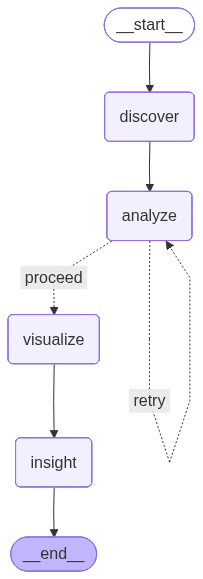

In [14]:
from IPython.display import Image, display

try:
    # Attempt to draw the graph using mermaid
    display(Image(app.get_graph().draw_mermaid_png()))
except Exception as e:
    print("Could not draw graph as PNG (requires pygraphviz/mermaid-python dependencies).")
    print("Mermaid Definition:")
    print(app.get_graph().draw_mermaid())

## 6. Execution Example
Run the complete pipeline for a natural language question.

**CRITICAL**: You MUST use `await` when calling `run_example` in a Jupyter notebook.

In [15]:
import asyncio

async def run_example(q: str):
    api_key = os.environ.get("GROQ_API_KEY")
    if not api_key or "your-key" in api_key:
        print("STOP: Please set a valid GROQ_API_KEY in Section 2.")
        return
        
    inputs = {"question": q, "retry_count": 0}
    print(f"Starting analysis for: '{q}'")
    
    async for output in app.astream(inputs):
        for node, data in output.items():
            print(f"\n--- Finished Node: {node} ---")
            if "error" in data and data["error"]:
                print(f"Error: {data['error']}")
            if "insight_report" in data:
                print("INSIGHT REPORT:")
                print(data["insight_report"])
            if "chart_json" in data and data["chart_json"]:
                print("Chart JSON Generated Successfully.")

In [16]:
# Execute the pipeline - AWAIT is required here!
await run_example("Who are the top 5 artists by number of tracks?")

Starting analysis for: 'Who are the top 5 artists by number of tracks?'

--- Finished Node: discover ---

--- Finished Node: analyze ---

--- Finished Node: visualize ---
Chart JSON Generated Successfully.

--- Finished Node: insight ---
INSIGHT REPORT:
Insight Report: Top 5 Artists by Number of Tracks

Based on the provided data, the top 5 artists by number of tracks are:

1. **Iron Maiden** with 213 tracks
2. **U2** with 135 tracks
3. **Led Zeppelin** with 114 tracks
4. **Metallica** with 112 tracks
5. **Lost** with 92 tracks

This ranking indicates that Iron Maiden has the most extensive discography among these artists, with over 78 more tracks than the second-ranked U2. The data suggests a significant gap between the top two artists and the rest of the list, with Led Zeppelin, Metallica, and Lost following closely behind.
